In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, cross_val_predict

# READ THE LOAN APPROVAL PREDICTION DATASET
loan_data = pd.read_csv("C:/Users/Admin/Documents/arc_model_core/ml_docs/Datasets/loan-approval-prediction.csv")
loan_data.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [2]:
# DISPLAY SUMMARY STATISTICS OF THE DATASET
loan_data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [3]:
# DISPLAY DATASET INFORMATION (DATA TYPES, NON-NULL COUNTS)
loan_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [4]:
# DISPLAY THE COUNT OF MISSING VALUES IN EACH COLUMN
print("\n:> MISSING VALUES BEFORE IMPUTATION >>")
loan_data.isnull().sum()


:> MISSING VALUES BEFORE IMPUTATION >>


Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [5]:
# IMPUTE NUMERICAL COLUMNS WITH MEAN VALUES
loan_data['LoanAmount'] = loan_data['LoanAmount'].fillna(loan_data['LoanAmount'].mean())
loan_data["Loan_Amount_Term"] = loan_data["Loan_Amount_Term"].fillna(loan_data['Loan_Amount_Term'].mean())
loan_data["Credit_History"] = loan_data["Credit_History"].fillna(loan_data["Credit_History"].mean())

# IMPUTE CATEGORICAL COLUMNS WITH MODE (MOST FREQUENT VALUES)
loan_data["Gender"] = loan_data["Gender"].fillna(loan_data["Gender"].mode()[0])
loan_data["Married"] = loan_data["Married"].fillna(loan_data["Married"].mode()[0])
loan_data["Dependents"] = loan_data["Dependents"].fillna(loan_data["Dependents"].mode()[0])
loan_data["Self_Employed"] = loan_data["Self_Employed"].fillna(loan_data["Self_Employed"].mode()[0])

In [6]:
# VERIFY THAT ALL MISSING VALUES HAVE BEEN HANDLED
print("\n:> MISSING VALUES AFTER IMPUTATION >>")
loan_data.isnull().sum()


:> MISSING VALUES AFTER IMPUTATION >>


Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64



<<========== GENDER VALUE COUNTs ==========>>


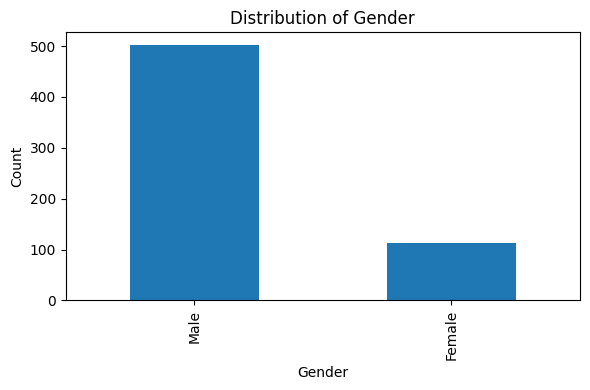



<<========== MARRIED VALUE COUNTs ==========>>


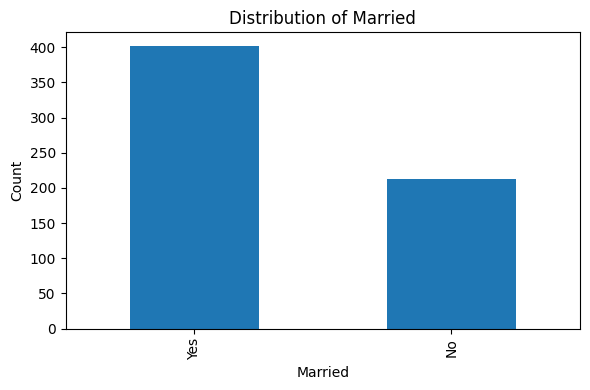



<<========== DEPENDENTS VALUE COUNTs ==========>>


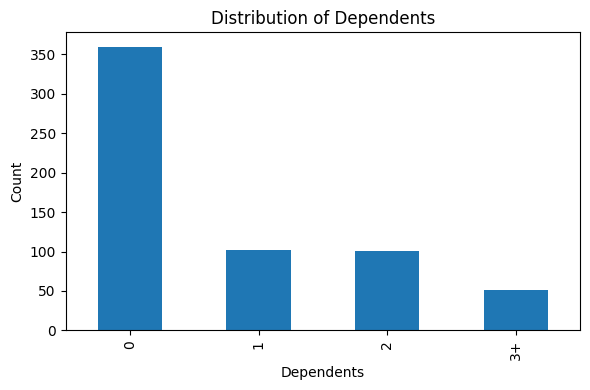



<<========== EDUCATION VALUE COUNTs ==========>>


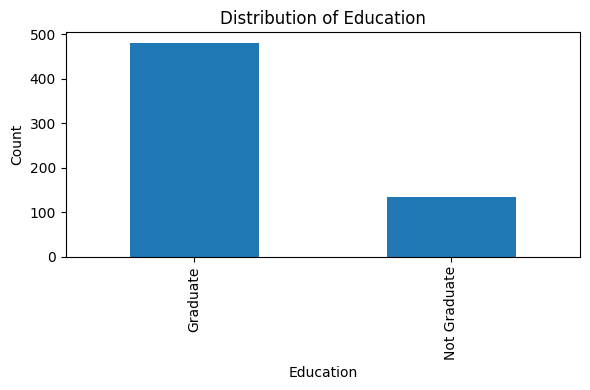



<<========== SELF_EMPLOYED VALUE COUNTs ==========>>


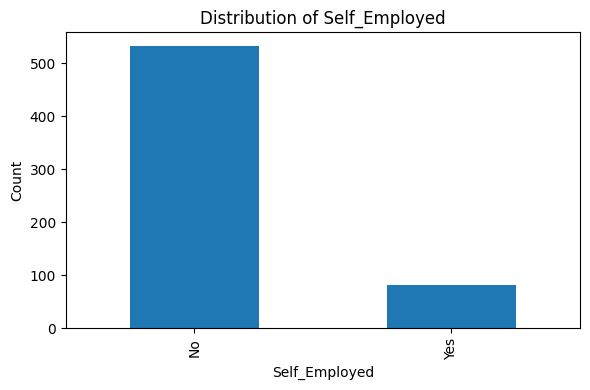



<<========== PROPERTY_AREA VALUE COUNTs ==========>>


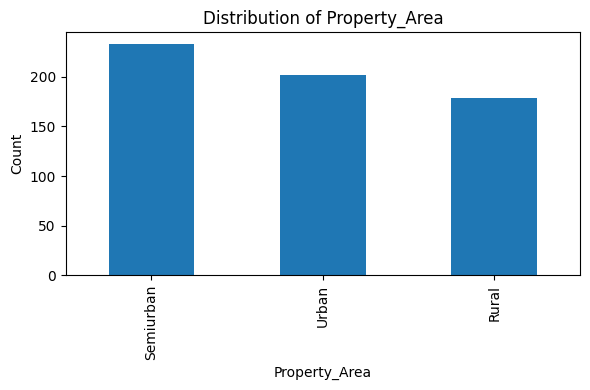



<<========== LOAN_STATUS VALUE COUNTs ==========>>


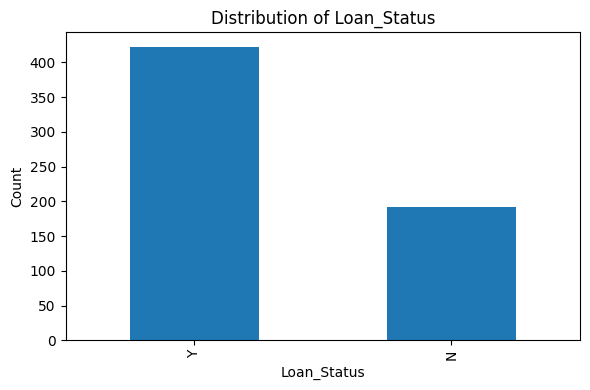

In [7]:
# DEFINE CATEGORICAL COLUMNS FOR VISUALIZATION
categorical_columns = ["Gender", "Married", "Dependents", "Education", "Self_Employed", "Property_Area", "Loan_Status"]

# DEFINE NUMERICAL COLUMNS FOR VISUALIZATION
numerical_columns = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term", "Credit_History"]


for col in categorical_columns:
    print(f"\n\n<<========== {col.upper()} VALUE COUNTs ==========>>")

    plt.figure(figsize=(6,4))
    loan_data[col].value_counts().plot(kind='bar')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()



<<========== DISTRIBUTION OF APPLICANTINCOME ==========>>


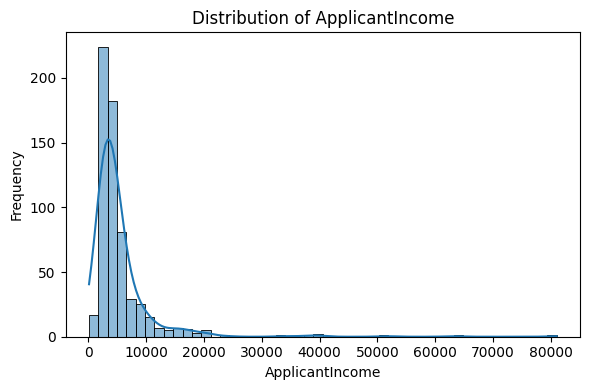



<<========== DISTRIBUTION OF COAPPLICANTINCOME ==========>>


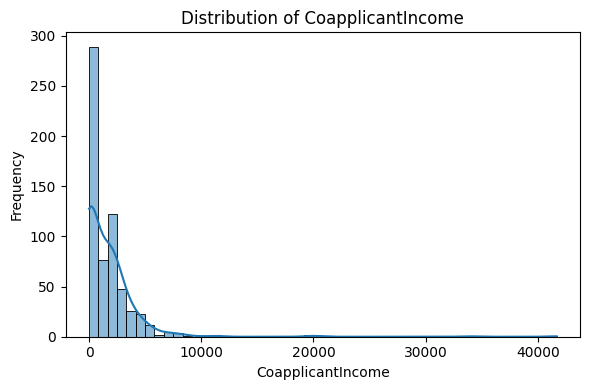



<<========== DISTRIBUTION OF LOANAMOUNT ==========>>


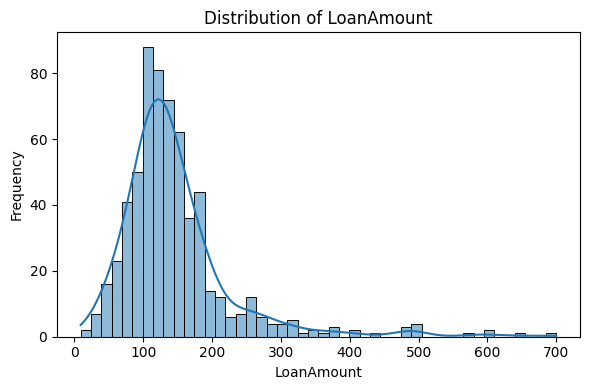



<<========== DISTRIBUTION OF LOAN_AMOUNT_TERM ==========>>


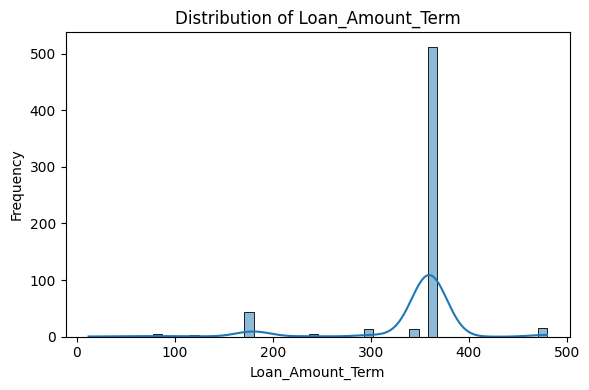



<<========== DISTRIBUTION OF CREDIT_HISTORY ==========>>


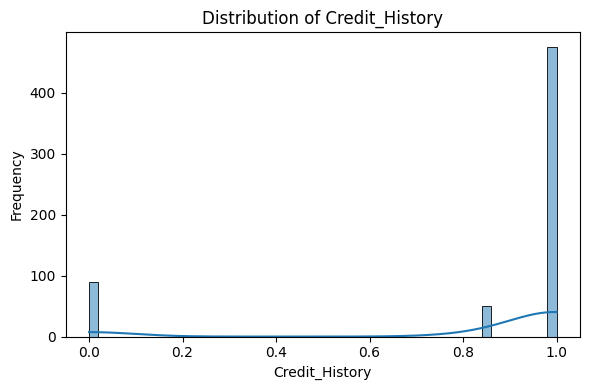

In [8]:
# VISUALIZE NUMERICAL COLUMNS USING HISTOGRAMS WITH KDE
for col in numerical_columns:
    print(f"\n\n<<========== DISTRIBUTION OF {col.upper()} ==========>>")

    plt.figure(figsize=(6,4))
    sns.histplot(loan_data[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [9]:
# CREATE NEW FEATURE: TOTAL INCOME (APPLICANT + CO-APPLICANT)
loan_data["Total_Income"] = (loan_data["ApplicantIncome"] + loan_data["CoapplicantIncome"])
print("\n:> DATAFRAME AFTER ADDING TOTAL_INCOME FEATURE >>")
loan_data.head(10)


:> DATAFRAME AFTER ADDING TOTAL_INCOME FEATURE >>


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,LP001002,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y,5849.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N,6091.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y,3000.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y,4941.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y,6000.0
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.000000,360.0,1.0,Urban,Y,9613.0
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.000000,360.0,1.0,Urban,Y,3849.0
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.000000,360.0,0.0,Semiurban,N,5540.0
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.000000,360.0,1.0,Urban,Y,5532.0
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.000000,360.0,1.0,Semiurban,N,23809.0



:> APPLYING LOG TRANSFORMATION TO NUMERICAL FEATURES >>


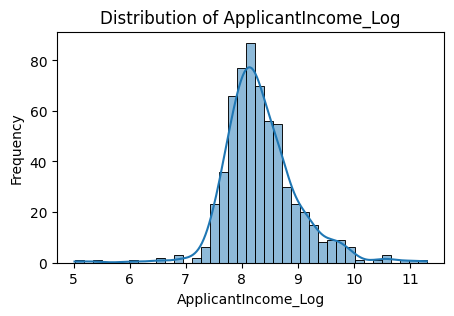

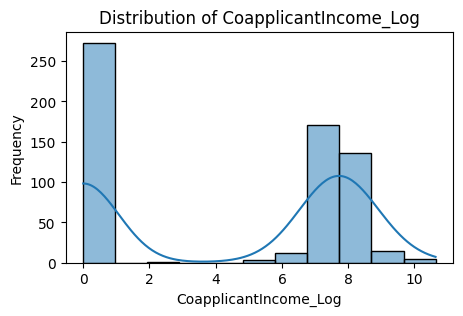

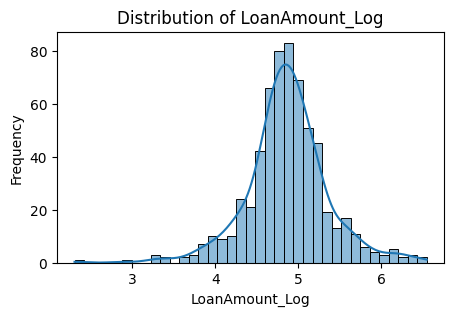

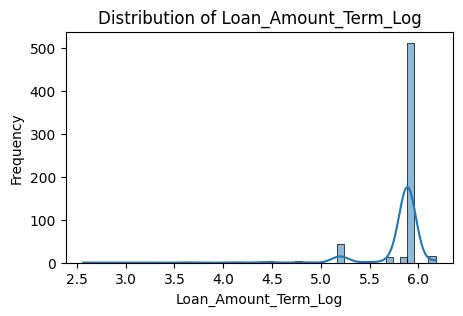

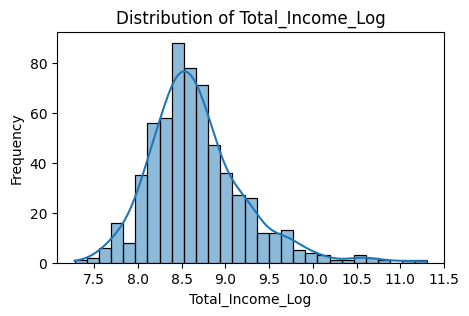

In [10]:
# DEFINE COLUMNS FOR LOG TRANSFORMATION
log_transformed_columns = ['ApplicantIncome_Log', 'CoapplicantIncome_Log', 'LoanAmount_Log', 'Loan_Amount_Term_Log', 'Total_Income_Log']
original_columns = ["ApplicantIncome", "CoapplicantIncome", 'LoanAmount', 'Loan_Amount_Term', 'Total_Income']


# APPLY LOG TRANSFORMATION TO REDUCE SKEWNESS
print("\n:> APPLYING LOG TRANSFORMATION TO NUMERICAL FEATURES >>")

for new, old in zip(log_transformed_columns, original_columns):
    loan_data[new] = np.log(loan_data[old] + 1)         # +1 TO HANDLE ZERO VALUES

    plt.figure(figsize=(5,3))
    sns.histplot(loan_data[new], kde=True)
    plt.title(f"Distribution of {new}")
    plt.xlabel(new)
    plt.ylabel("Frequency")
    plt.show()

In [11]:
# DISPLAY DATAFRAME AFTER LOG TRANSFORMATIONS
loan_data.head(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,ApplicantIncome_Log,CoapplicantIncome_Log,LoanAmount_Log,Loan_Amount_Term_Log,Total_Income_Log
0,LP001002,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y,5849.0,8.674197,0.000000,4.993232,5.888878,8.674197
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N,6091.0,8.430327,7.319202,4.859812,5.888878,8.714732
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y,3000.0,8.006701,0.000000,4.204693,5.888878,8.006701
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y,4941.0,7.857094,7.765993,4.795791,5.888878,8.505525
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y,6000.0,8.699681,0.000000,4.955827,5.888878,8.699681
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.000000,360.0,1.0,Urban,Y,9613.0,8.597482,8.342125,5.590987,5.888878,9.170976
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.000000,360.0,1.0,Urban,Y,3849.0,7.755339,7.324490,4.564348,5.888878,8.255828
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.000000,360.0,0.0,Semiurban,N,5540.0,8.018625,7.826044,5.068904,5.888878,8.619930
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.000000,360.0,1.0,Urban,Y,5532.0,8.295798,7.331060,5.129899,5.888878,8.618485
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.000000,360.0,1.0,Semiurban,N,23809.0,9.460476,9.302828,5.857933,5.888878,10.077861


In [12]:
# DEFINE COLUMNS TO DROP (ORIGINAL UNTRANSFORMED COLUMNS)
columns_to_drop = [
    "Loan_ID",
    "LoanAmount",
    "Total_Income",
    "ApplicantIncome",
    "Loan_Amount_Term",
    "CoapplicantIncome",
]

# REMOVE UNNECESSARY COLUMNS FROM THE DATASET
processed_loan_data = loan_data.drop(columns=columns_to_drop)

print("\n:> DATAFRAME AFTER DROPPING UNNECESSARY COLUMNS >>")
processed_loan_data.head(10)


:> DATAFRAME AFTER DROPPING UNNECESSARY COLUMNS >>


,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,Loan_Status,ApplicantIncome_Log,CoapplicantIncome_Log,LoanAmount_Log,Loan_Amount_Term_Log,Total_Income_Log
0,Male,No,0,Graduate,No,1.0,Urban,Y,8.674197,0.000000,4.993232,5.888878,8.674197
1,Male,Yes,1,Graduate,No,1.0,Rural,N,8.430327,7.319202,4.859812,5.888878,8.714732
2,Male,Yes,0,Graduate,Yes,1.0,Urban,Y,8.006701,0.000000,4.204693,5.888878,8.006701
3,Male,Yes,0,Not Graduate,No,1.0,Urban,Y,7.857094,7.765993,4.795791,5.888878,8.505525
4,Male,No,0,Graduate,No,1.0,Urban,Y,8.699681,0.000000,4.955827,5.888878,8.699681
5,Male,Yes,2,Graduate,Yes,1.0,Urban,Y,8.597482,8.342125,5.590987,5.888878,9.170976
6,Male,Yes,0,Not Graduate,No,1.0,Urban,Y,7.755339,7.324490,4.564348,5.888878,8.255828
7,Male,Yes,3+,Graduate,No,0.0,Semiurban,N,8.018625,7.826044,5.068904,5.888878,8.619930
8,Male,Yes,2,Graduate,No,1.0,Urban,Y,8.295798,7.331060,5.129899,5.888878,8.618485
9,Male,Yes,1,Graduate,No,1.0,Semiurban,N,9.460476,9.302828,5.857933,5.888878,10.077861


In [13]:
# DEFINE CATEGORICAL COLUMNS FOR LABEL ENCODING
categorical_to_encode = [
    "Gender",
    "Married",
    "Education",
    "Dependents",
    "Loan_Status",
    "Property_Area",
    "Self_Employed",
]

# INITIALIZE LABEL ENCODER
label_encoder = LabelEncoder()

# APPLY LABEL ENCODING TO CATEGORICAL COLUMNS
for col in categorical_to_encode:
    processed_loan_data[col] = label_encoder.fit_transform(processed_loan_data[col])

In [14]:
# DISPLAY DATAFRAME AFTER LABEL ENCODING
print("\n:> DATAFRAME AFTER LABEL ENCODING >>")
processed_loan_data.head(10)


:> DATAFRAME AFTER LABEL ENCODING >>


,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,Loan_Status,ApplicantIncome_Log,CoapplicantIncome_Log,LoanAmount_Log,Loan_Amount_Term_Log,Total_Income_Log
0,1,0,0,0,0,1.0,2,1,8.674197,0.000000,4.993232,5.888878,8.674197
1,1,1,1,0,0,1.0,0,0,8.430327,7.319202,4.859812,5.888878,8.714732
2,1,1,0,0,1,1.0,2,1,8.006701,0.000000,4.204693,5.888878,8.006701
3,1,1,0,1,0,1.0,2,1,7.857094,7.765993,4.795791,5.888878,8.505525
4,1,0,0,0,0,1.0,2,1,8.699681,0.000000,4.955827,5.888878,8.699681
5,1,1,2,0,1,1.0,2,1,8.597482,8.342125,5.590987,5.888878,9.170976
6,1,1,0,1,0,1.0,2,1,7.755339,7.324490,4.564348,5.888878,8.255828
7,1,1,3,0,0,0.0,1,0,8.018625,7.826044,5.068904,5.888878,8.619930
8,1,1,2,0,0,1.0,2,1,8.295798,7.331060,5.129899,5.888878,8.618485
9,1,1,1,0,0,1.0,1,0,9.460476,9.302828,5.857933,5.888878,10.077861


In [15]:
# VERIFY DATA TYPES AFTER ENCODING
print("\n:> DATA TYPES AFTER PROCESSING >>")
processed_loan_data.info()


:> DATA TYPES AFTER PROCESSING >>
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Gender                 614 non-null    int64  
 1   Married                614 non-null    int64  
 2   Dependents             614 non-null    int64  
 3   Education              614 non-null    int64  
 4   Self_Employed          614 non-null    int64  
 5   Credit_History         614 non-null    float64
 6   Property_Area          614 non-null    int64  
 7   Loan_Status            614 non-null    int64  
 8   ApplicantIncome_Log    614 non-null    float64
 9   CoapplicantIncome_Log  614 non-null    float64
 10  LoanAmount_Log         614 non-null    float64
 11  Loan_Amount_Term_Log   614 non-null    float64
 12  Total_Income_Log       614 non-null    float64
dtypes: float64(6), int64(7)
memory usage: 62.5 KB


In [16]:
# SEPARATE FEATURES (X) AND TARGET VARIABLE (y)
X = processed_loan_data.drop(columns=['Loan_Status'], axis=0)
y = processed_loan_data['Loan_Status']

# SPLIT THE DATA INTO TRAINING AND TESTING SETS (75% TRAIN, 25% TEST)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# INITIALIZE AND TRAIN LOGISTIC REGRESSION MODEL
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train)

# MAKE PREDICTIONS ON THE TEST SET
y_predicted = logistic_model.predict(X_test)

In [17]:
# CALCULATE AND DISPLAY MODEL ACCURACY
model_accuracy = logistic_model.score(X_test, y_test) * 100
print(f":> MODEL ACCURACY: {model_accuracy:.2f} %")

:> MODEL ACCURACY: 77.27 %


In [18]:
# GENERATE CONFUSION MATRIX
confusion_mat = confusion_matrix(y_test, y_predicted)

print(":> CONFUSION MATRIX:")
confusion_mat

:> CONFUSION MATRIX:


array([[21, 33],
       [ 2, 98]])

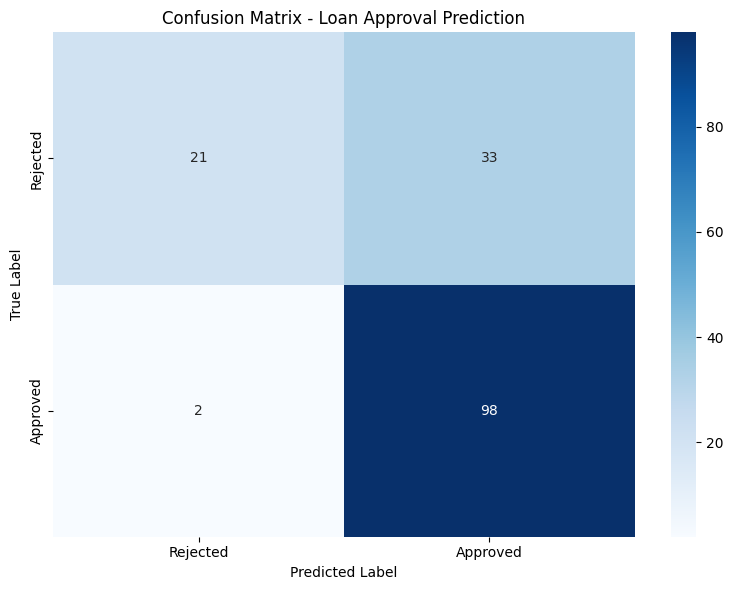

In [19]:
# VISUALIZE CONFUSION MATRIX USING HEATMAP
plt.figure(figsize=(8,6))
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
plt.title("Confusion Matrix - Loan Approval Prediction")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [20]:
# OPTIONAL: DISPLAY CLASSIFICATION SUMMARY
print("\n:> CLASSIFICATION REPORT >>")
print(classification_report(y_test, y_predicted, target_names=['Rejected', 'Approved']))


:> CLASSIFICATION REPORT >>
              precision    recall  f1-score   support

    Rejected       0.91      0.39      0.55        54
    Approved       0.75      0.98      0.85       100

    accuracy                           0.77       154
   macro avg       0.83      0.68      0.70       154
weighted avg       0.81      0.77      0.74       154

